In [2]:
# =========================
# IMPORTS
# =========================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

# =========================
# CONFIG
# =========================
train_val_dir = r"C:\Computer Vision Project\archive (2)\lung_colon_image_set\Train and Validation Set"
test_dir      = r"C:\Computer Vision Project\archive (2)\lung_colon_image_set\Test Set"

IMG_SIZE = 224
BATCH_SIZE = 16
SEED = 42
EPOCHS = 25

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
TARGET_CLASSES = ['lung_aca', 'lung_n', 'lung_scc']

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [5]:
class FilteredImageFolder(Dataset):
    def __init__(self, root_dir, classes, transform=None):
        self.dataset = datasets.ImageFolder(root=root_dir)
        self.transform = transform

        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}
        self.samples = []

        for path, label in self.dataset.samples:
            class_name = self.dataset.classes[label]
            if class_name in classes:
                self.samples.append((path, self.class_to_idx[class_name]))

        self.classes = classes

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
full_dataset = FilteredImageFolder(
    root_dir=train_val_dir,
    classes=TARGET_CLASSES,
    transform=train_transform
)

print("Total Images:", len(full_dataset))

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Fix validation transform
val_dataset.dataset.transform = val_test_transform

test_dataset = FilteredImageFolder(
    root_dir=test_dir,
    classes=TARGET_CLASSES,
    transform=val_test_transform
)

Total Images: 13501


In [7]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names = TARGET_CLASSES

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 10800
Val: 2701
Test: 1499


In [8]:
start = time.time()

for images, labels in train_loader:
    print("Batch shape:", images.shape)
    break

print("Time:", time.time() - start)

Batch shape: torch.Size([16, 3, 224, 224])
Time: 0.8120131492614746


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.046885163..1.08956].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.011764705..1.08956].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.03485787..1.0656123].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.19923112..1.08956].


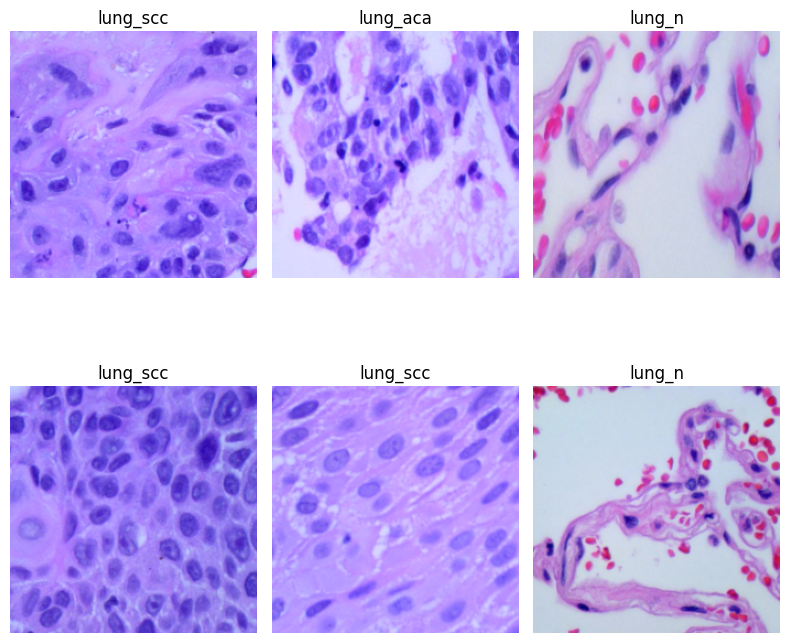

In [9]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(8,8))
for i in range(6):
    plt.subplot(2,3,i+1)
    img = images[i].permute(1,2,0).numpy()
    img = (img * 0.229 + 0.485)  # unnormalize approx
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

# Freeze early layers
for param in model.features[:5].parameters():
    param.requires_grad = False

# Unfreeze deeper layers
for param in model.features[5:].parameters():
    param.requires_grad = True

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 3)
)

model = model.to(device)

In [11]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.3
)

In [12]:
def train_model(model, train_loader, val_loader, epochs=25):
    best_acc = 0
    patience = 5
    counter = 0

    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        correct = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

        train_acc = correct / len(train_loader.dataset)

        # Validation
        model.eval()
        val_correct = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: Train={train_acc:.4f}, Val={val_acc:.4f}")

        scheduler.step(val_acc)

        # Early stopping
        if val_acc > best_acc:
            best_acc = val_acc
            counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping triggered")
            break

    return train_accs, val_accs

In [13]:
train_accs, val_accs = train_model(model, train_loader, val_loader, epochs=EPOCHS)

Epoch 1: Train=0.9611, Val=0.9981
Epoch 2: Train=0.9918, Val=0.9985
Epoch 3: Train=0.9956, Val=0.9930
Epoch 4: Train=0.9953, Val=0.9989
Epoch 5: Train=0.9969, Val=0.9993
Epoch 6: Train=0.9974, Val=0.9948
Epoch 7: Train=0.9971, Val=0.9922
Epoch 8: Train=0.9970, Val=0.9989
Epoch 9: Train=0.9990, Val=0.9996
Epoch 10: Train=0.9997, Val=0.9996
Epoch 11: Train=1.0000, Val=1.0000
Epoch 12: Train=0.9998, Val=1.0000
Epoch 13: Train=0.9996, Val=1.0000
Epoch 14: Train=0.9995, Val=0.9996
Epoch 15: Train=0.9994, Val=0.9996
Epoch 16: Train=0.9999, Val=0.9996
Early stopping triggered


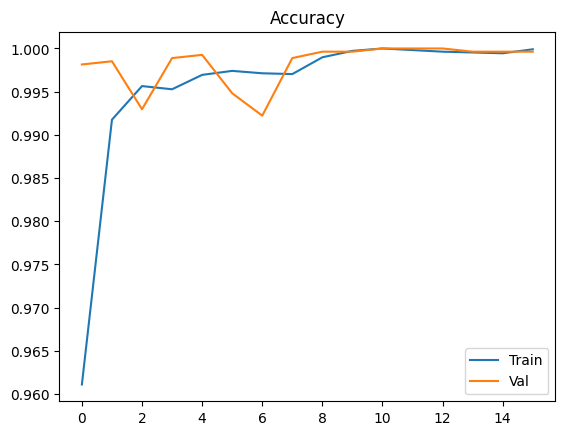

In [14]:
plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Val')
plt.legend()
plt.title("Accuracy")
plt.show()

In [15]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    lung_aca       1.00      1.00      1.00       500
      lung_n       1.00      1.00      1.00       500
    lung_scc       1.00      1.00      1.00       499

    accuracy                           1.00      1499
   macro avg       1.00      1.00      1.00      1499
weighted avg       1.00      1.00      1.00      1499



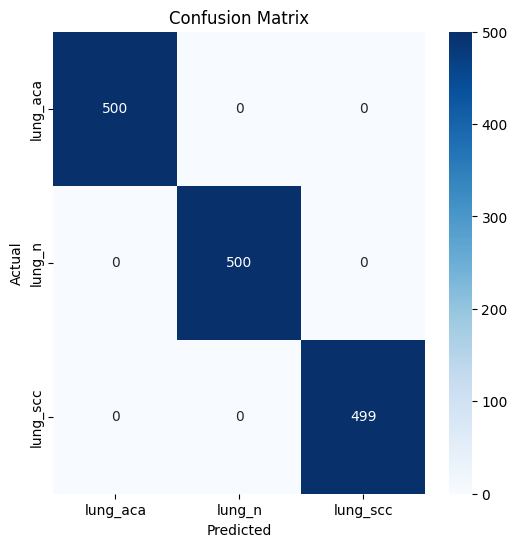

In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:
# =========================
# LOAD TRAINED MODEL
# =========================
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Recreate SAME model architecture
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

# Freeze/unfreeze EXACTLY like training
for param in model.features[:5].parameters():
    param.requires_grad = False
for param in model.features[5:].parameters():
    param.requires_grad = True

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 3)
)

# Load trained weights
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model = model.to(device)
model.eval()

print("Model loaded successfully")

Model loaded successfully


In [18]:
# =========================
# TARGET LAYER FOR GRAD-CAM
# =========================

target_layer = model.features[-1]  # Last conv layer

print(target_layer)

Conv2dNormActivation(
  (0): Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)


In [19]:
# =========================
# GRAD-CAM IMPLEMENTATION
# =========================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        
        self.gradients = None
        self.activations = None

        # Hook for forward pass
        self.target_layer.register_forward_hook(self.forward_hook)
        # Hook for backward pass
        self.target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output.detach()

    def backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, input_tensor, class_idx=None):
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = torch.argmax(output)

        self.model.zero_grad()
        output[0, class_idx].backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        # Global average pooling of gradients
        weights = torch.mean(gradients, dim=(1, 2))

        # Weighted combination
        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)

        # Normalize
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam.cpu().numpy()

In [20]:
# =========================
# RANDOM IMAGE SELECTION
# =========================

import random
import os
from PIL import Image

def get_random_images(root_dir, classes, n_images):
    all_images = []

    for cls in classes:
        class_path = os.path.join(root_dir, cls)
        images = [os.path.join(class_path, img) for img in os.listdir(class_path)]
        all_images.extend(images)

    selected = random.sample(all_images, n_images)
    return selected

# USER INPUT
n_images = int(input("Enter number of images: "))

image_paths = get_random_images(test_dir, class_names, n_images)

print(f"Selected {len(image_paths)} images")

Enter number of images:  10


Selected 10 images


In [21]:
# =========================
# PREPROCESS FUNCTION
# =========================

import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def preprocess_image(path):
    image = Image.open(path).convert("RGB")
    tensor = transform(image).unsqueeze(0)
    return image, tensor.to(device)

D:\anaconda3\envs\venv\lib\site-packages\torch\nn\modules\module.py:1639: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


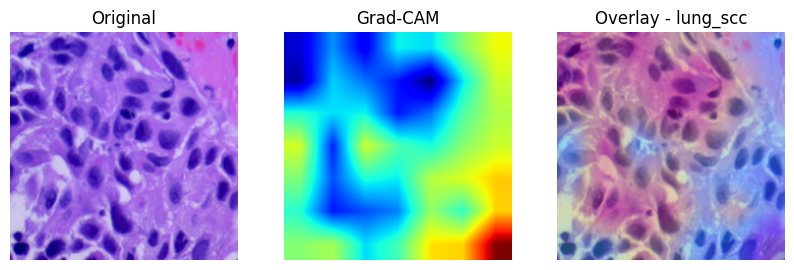

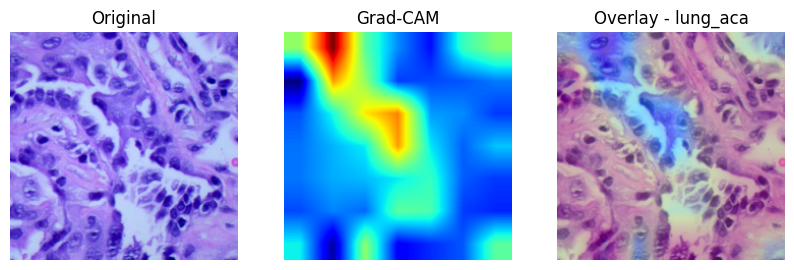

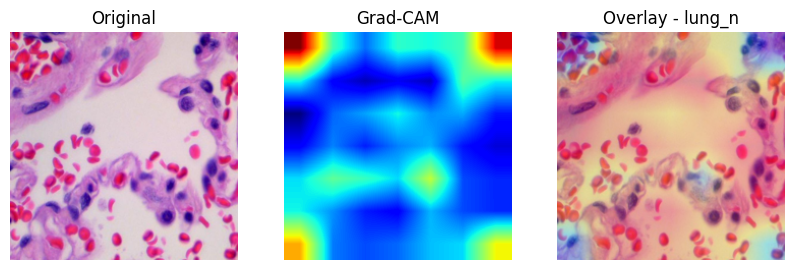

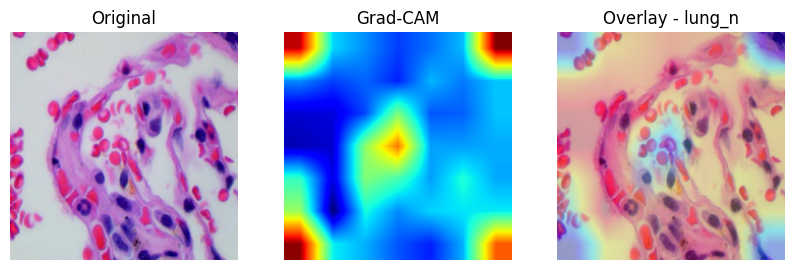

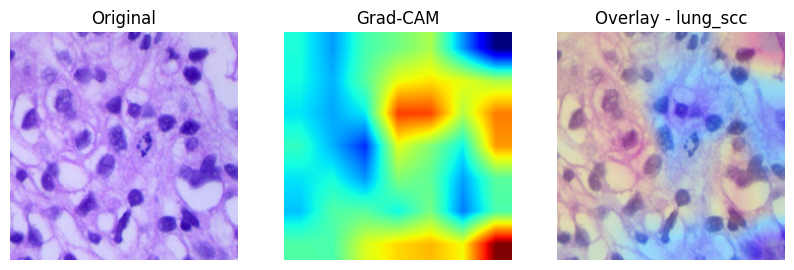

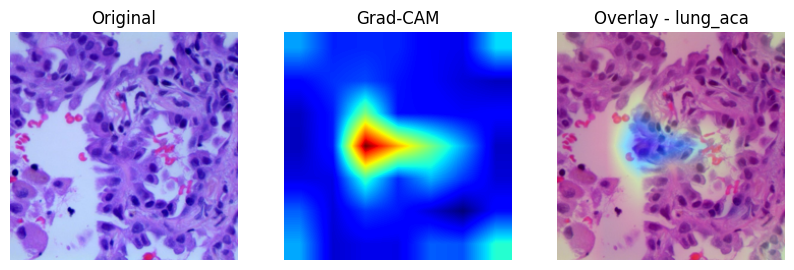

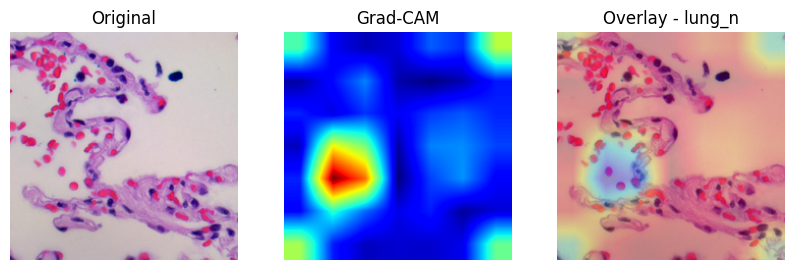

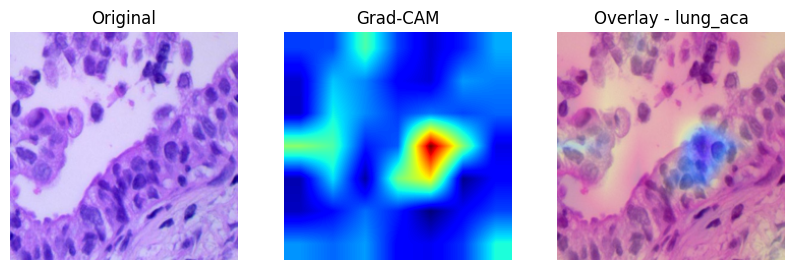

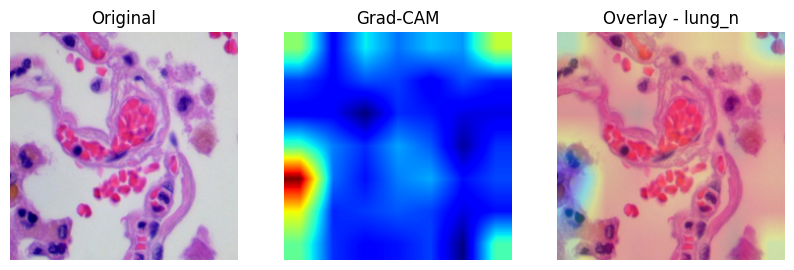

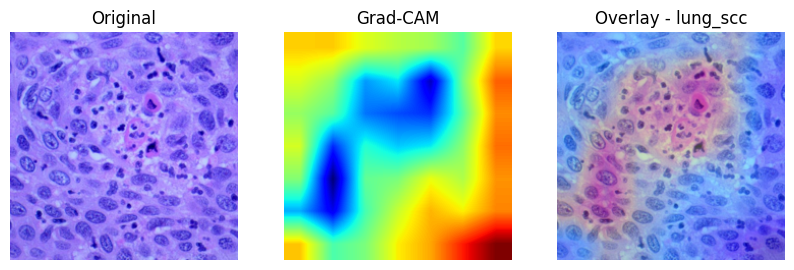

In [22]:
# =========================
# VISUALIZATION
# =========================

import matplotlib.pyplot as plt
import cv2
import numpy as np

gradcam = GradCAM(model, target_layer)

for path in image_paths:
    original_image, input_tensor = preprocess_image(path)

    cam = gradcam.generate(input_tensor)

    # Resize CAM to image size
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    original_np = np.array(original_image.resize((IMG_SIZE, IMG_SIZE))) / 255

    overlay = heatmap * 0.4 + original_np
    overlay = overlay / np.max(overlay)

    # Prediction
    output = model(input_tensor)
    pred_class = torch.argmax(output).item()

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(original_np)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(cam, cmap='jet')
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title(f"Overlay - {class_names[pred_class]}")
    plt.axis("off")

    plt.show()

In [45]:
# =========================
# LOAD MODEL
# =========================
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

for param in model.features[:5].parameters():
    param.requires_grad = False
for param in model.features[5:].parameters():
    param.requires_grad = True

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 3)
)

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model = model.to(device)
model.eval()

print("Model Loaded")

Model Loaded


In [46]:
# =========================
# BALANCED RANDOM SAMPLING
# =========================
import os
import random

test_dir = r"C:\Computer Vision Project\archive (2)\lung_colon_image_set\Test Set"

class_names = ['lung_aca', 'lung_n', 'lung_scc']

image_paths = []
labels = []

total_samples = 50
samples_per_class = total_samples // len(class_names)  # ~16 each

for idx, cls in enumerate(class_names):
    class_path = os.path.join(test_dir, cls)
    
    all_imgs = os.listdir(class_path)
    selected_imgs = random.sample(all_imgs, samples_per_class)

    for img in selected_imgs:
        image_paths.append(os.path.join(class_path, img))
        labels.append(idx)

# Shuffle to remove ordering bias
combined = list(zip(image_paths, labels))
random.shuffle(combined)
image_paths, labels = zip(*combined)

print("Total selected:", len(image_paths))
print("Class distribution:", {cls: labels.count(i) for i, cls in enumerate(class_names)})

Total selected: 48
Class distribution: {'lung_aca': 16, 'lung_n': 16, 'lung_scc': 16}


In [47]:
# =========================
# TRANSFORM
# =========================
import torchvision.transforms as transforms
from PIL import Image

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [48]:
# =========================
# NOISE FUNCTION
# =========================
def add_noise(tensor, noise_level=0.03):
    noise = torch.randn_like(tensor) * noise_level
    noisy = tensor + noise
    return torch.clamp(noisy, -2, 2)

In [49]:
# =========================
# INFERENCE
# =========================
import numpy as np

y_true = []
y_pred_original = []
y_pred_noisy = []

flip_count = 0

for path, label in zip(image_paths, labels):
    image = Image.open(path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    # Original prediction
    with torch.no_grad():
        output = model(input_tensor)
        pred_orig = torch.argmax(output).item()

    # Noisy prediction
    noisy_input = add_noise(input_tensor.clone())

    with torch.no_grad():
        output_noisy = model(noisy_input)
        pred_noisy = torch.argmax(output_noisy).item()

    # Store results
    y_true.append(label)
    y_pred_original.append(pred_orig)
    y_pred_noisy.append(pred_noisy)

    if pred_orig != pred_noisy:
        flip_count += 1

In [50]:
# =========================
# EVALUATION
# =========================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("\n===== ORIGINAL PERFORMANCE =====")
print("Accuracy:", accuracy_score(y_true, y_pred_original))
print(classification_report(y_true, y_pred_original, labels=[0,1,2], target_names=class_names))

print("\n===== NOISY PERFORMANCE =====")
print("Accuracy:", accuracy_score(y_true, y_pred_noisy))
print(classification_report(y_true, y_pred_noisy, labels=[0,1,2], target_names=class_names))

print("\n===== STABILITY ANALYSIS =====")
print("Total Samples:", len(y_true))
print("Prediction Flips:", flip_count)
print("Flip %:", (flip_count / len(y_true)) * 100)


===== ORIGINAL PERFORMANCE =====
Accuracy: 1.0
              precision    recall  f1-score   support

    lung_aca       1.00      1.00      1.00        16
      lung_n       1.00      1.00      1.00        16
    lung_scc       1.00      1.00      1.00        16

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48


===== NOISY PERFORMANCE =====
Accuracy: 0.9791666666666666
              precision    recall  f1-score   support

    lung_aca       1.00      0.94      0.97        16
      lung_n       1.00      1.00      1.00        16
    lung_scc       0.94      1.00      0.97        16

    accuracy                           0.98        48
   macro avg       0.98      0.98      0.98        48
weighted avg       0.98      0.98      0.98        48


===== STABILITY ANALYSIS =====
Total Samples: 48
Prediction Flips: 1
Flip %: 2.083333333333333


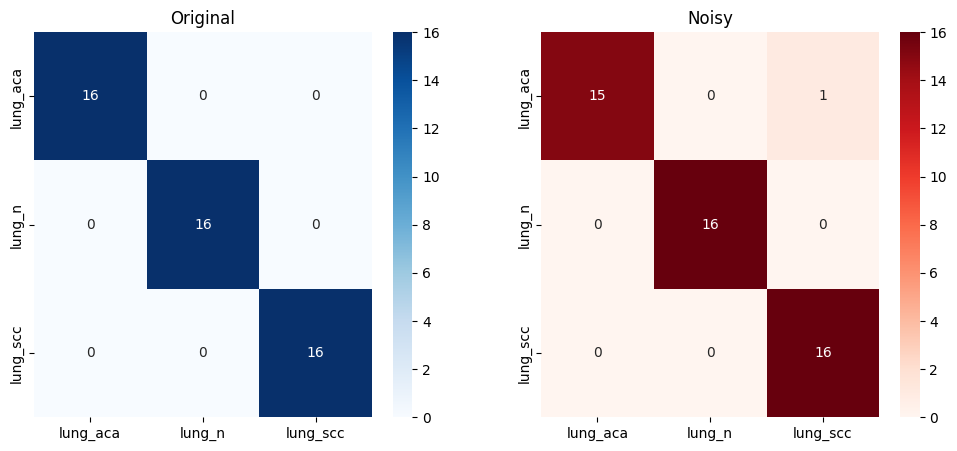

In [51]:
# =========================
# CONFUSION MATRICES
# =========================
import seaborn as sns
import matplotlib.pyplot as plt

cm_orig = confusion_matrix(y_true, y_pred_original, labels=[0,1,2])
cm_noisy = confusion_matrix(y_true, y_pred_noisy, labels=[0,1,2])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Original")

plt.subplot(1,2,2)
sns.heatmap(cm_noisy, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Noisy")

plt.show()

In [52]:
# =========================
# FEATURE EXTRACTOR
# =========================
def extract_features(model, x):
    with torch.no_grad():
        x = model.features(x)
        x = model.avgpool(x)
        x = torch.flatten(x, 1)
    return x

In [53]:
# =========================
# COLLECT FEATURES
# =========================
import numpy as np

features_list = []
labels_list = []

model.eval()

for images, labels in train_loader:
    images = images.to(device)

    feats = extract_features(model, images)
    
    features_list.append(feats.cpu().numpy())
    labels_list.append(labels.numpy())

features = np.concatenate(features_list, axis=0)
labels = np.concatenate(labels_list, axis=0)

print("Feature shape:", features.shape)

Feature shape: (10800, 1280)


In [54]:
# =========================
# CLASS MEANS
# =========================
class_means = {}

for i in range(len(class_names)):
    class_features = features[labels == i]
    class_means[i] = np.mean(class_features, axis=0)

print("Computed class means")

Computed class means


In [55]:
# =========================
# SHARED COVARIANCE
# =========================
from sklearn.covariance import EmpiricalCovariance

cov = EmpiricalCovariance().fit(features)
cov_matrix = cov.covariance_
inv_cov_matrix = np.linalg.inv(cov_matrix)

print("Covariance computed")

Covariance computed


In [56]:
# =========================
# SAVE FILES
# =========================
np.save("class_means.npy", class_means)
np.save("inv_cov.npy", inv_cov_matrix)

print("Saved OOD statistics")

Saved OOD statistics


In [57]:
# =========================
# MAHALANOBIS DISTANCE
# =========================
def mahalanobis_distance(feature, class_means, inv_cov):
    distances = []
    
    for i in class_means:
        mean = class_means[i]
        diff = feature - mean
        dist = np.dot(np.dot(diff, inv_cov), diff.T)
        distances.append(dist)
    
    return min(distances)

In [58]:
# =========================
# THRESHOLD SELECTION
# =========================
distances = []

for i in range(len(features)):
    dist = mahalanobis_distance(features[i], class_means, inv_cov_matrix)
    distances.append(dist)

threshold = np.percentile(distances, 95)  # 95% confidence

print("Threshold:", threshold)

Threshold: 2396.043794460053


In [59]:
np.save("threshold.npy", threshold)

In [60]:
# =========================
# LOAD COLON DATA
# =========================
colon_dir = r"C:\Computer Vision Project\archive (2)\lung_colon_image_set\Test Set"

colon_classes = ['colon_aca', 'colon_n']  # adjust if needed

colon_dataset = FilteredImageFolder(
    root_dir=colon_dir,
    classes=colon_classes,
    transform=val_test_transform
)

colon_loader = DataLoader(colon_dataset, batch_size=16, shuffle=False)

print("Colon samples:", len(colon_dataset))

Colon samples: 1000


In [62]:
# =========================
# COLLECT LUNG FEATURES
# =========================
lung_features_list = []
lung_labels_list = []

for images, labels in train_loader:
    images = images.to(device)
    feats = extract_features(model, images)
    
    lung_features_list.append(feats.cpu().numpy())
    lung_labels_list.append(labels.numpy())

lung_features = np.concatenate(lung_features_list)
lung_labels = np.concatenate(lung_labels_list)

print("Lung features:", lung_features.shape)

Lung features: (10800, 1280)


In [63]:
# =========================
# COLLECT COLON FEATURES
# =========================
colon_features_list = []

for images, _ in colon_loader:
    images = images.to(device)
    feats = extract_features(model, images)
    
    colon_features_list.append(feats.cpu().numpy())

colon_features = np.concatenate(colon_features_list)

print("Colon features:", colon_features.shape)

Colon features: (1000, 1280)


In [64]:
class_means = {}

for i in range(len(class_names)):
    class_means[i] = np.mean(lung_features[lung_labels == i], axis=0)

In [65]:
cov = EmpiricalCovariance().fit(lung_features)
cov_matrix = cov.covariance_
inv_cov_matrix = np.linalg.inv(cov_matrix)

In [66]:
# =========================
# LUNG DISTANCES
# =========================
lung_distances = []

for f in lung_features:
    d = mahalanobis_distance(f, class_means, inv_cov_matrix)
    lung_distances.append(d)

lung_distances = np.array(lung_distances)

In [67]:
# =========================
# COLON DISTANCES
# =========================
colon_distances = []

for f in colon_features:
    d = mahalanobis_distance(f, class_means, inv_cov_matrix)
    colon_distances.append(d)

colon_distances = np.array(colon_distances)

In [68]:
lung_max = np.percentile(lung_distances, 95)
colon_min = np.percentile(colon_distances, 5)

threshold = (lung_max + colon_min) / 2

print("New threshold:", threshold)

New threshold: 1634.7184916706433


In [69]:
np.save("threshold_final.npy", threshold)
print("Updated threshold saved")

Updated threshold saved


------------------------------OOD for Colon-------------------------